# Teste inicial da base de dados — NCBI Pathogen Detection

Objetivo desse notebook: **importar a base e conferir se está tudo funcionando.**

1. O arquivo abre certo?
2. As colunas que a gente precisa estão lá?
3. Tem dado suficiente para trabalhar depois?

---
## Passo 0 — Bibliotecas


In [32]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn xgboost jinja2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split, GroupShuffleSplit, StratifiedGroupKFold
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix
from xgboost import XGBClassifier

---

# Como importar
Os dados vêm daqui: **https://www.ncbi.nlm.nih.gov/pathogens/isolates**

No site (leva uns 2 minutos):

1. Abre o link (é o **Isolates Browser** do Pathogen Detection).
2. Em **Filters**, escolhe um **Organism group**.
   Sugestão pro primeiro teste: **Salmonella enterica** — é o grupo com mais
   resultado de teste de laboratório disponível.
3. Em **Choose columns**, marca estas duas colunas:
   - **AMR genotypes** → os genes de resistência que aquela bactéria tem
   - **AST phenotypes** → o resultado real do teste de laboratório
4. Clica em **Download** e baixa como tabela (TSV ou CSV).


---
## Passo 2 — Importar a base

A célula abaixo abre uma janelinha para você escolher o arquivo que baixou.

In [33]:
caminho = "dados/neisseria-gonorrheae.csv"
with open(caminho, encoding="utf-8", errors="ignore") as f:
    primeira_linha = f.readline()
separador = "\t" if primeira_linha.count("\t") > primeira_linha.count(",") else ","

df = pd.read_csv(caminho, sep=separador, low_memory=False)

print(f"Linhas (isolados): {len(df):,}")
print(f"Colunas: {len(df.columns)}")

Linhas (isolados): 72,503
Colunas: 18


### Visualizando tabela

In [34]:
print(df.head())

print(df.columns.tolist())

         #Organism group     Strain                 Isolate identifiers  \
0  Neisseria gonorrhoeae    FA 1090  "AE004969","ERS28491451","FA 1090"   
1  Neisseria gonorrhoeae  NCCP11945              "CP001050","NCCP11945"   
2  Neisseria gonorrhoeae       1291                       "1291","ABZF"   
3  Neisseria gonorrhoeae      35/02                      "35/02","ABZG"   
4  Neisseria gonorrhoeae      DGI18                      "ABZH","DGI18"   

  Serovar         Isolate           Create date Location Isolation source  \
0     NaN  PDT000004444.2  2011-02-17T22:24:00Z      NaN              NaN   
1     NaN  PDT000005014.2  2010-05-12T22:44:00Z      NaN              NaN   
2     NaN  PDT000005594.2  2010-10-15T22:45:00Z      NaN              NaN   
3     NaN  PDT000005595.2  2010-10-15T22:45:00Z      NaN              NaN   
4     NaN  PDT000005596.2  2010-10-15T22:45:00Z      NaN              NaN   

  Isolation type  Food origin     SNP cluster  Min-same  Min-diff  \
0            NaN 

In [35]:
def tabela(dados, linhas=5, max_texto=45):
    def limpar(v):
        if pd.isna(v):
            return "—"
        t = str(v)
        return t[:max_texto] + " …" if len(t) > max_texto else t

    return (dados.head(linhas).style
        .hide(axis="index")
        .format(limpar)
        .set_table_styles([
            {"selector": "th", "props": "background:#A8D5E8; color:#14384A; font-weight:600;"
                                        "text-align:left; padding:11px 14px;"},
            {"selector": "td", "props": "background:#FFFFFF; color:#22333B; padding:10px 14px;"
                                        "text-align:left; border-top:1px solid #DCEAF2;"
                                        "white-space:nowrap;"},
            {"selector": "tbody tr:nth-child(even) td", "props": "background:#F4FAFD;"},
        ]))

tabela(df)

#Organism group,Strain,Isolate identifiers,Serovar,Isolate,Create date,Location,Isolation source,Isolation type,Food origin,SNP cluster,Min-same,Min-diff,BioSample,Assembly,AST phenotypes,AMR genotypes,Computed types
Neisseria gonorrhoeae,FA 1090,"""AE004969"",""ERS28491451"",""FA 1090""",—,PDT000004444.2,2011-02-17T22:24:00Z,—,—,—,—,—,—,—,SAMN02604088,GCA_000006845.1,—,"farB=COMPLETE,mtrA=COMPLETE,mtrC=COMPLETE,mtr …",—
Neisseria gonorrhoeae,NCCP11945,"""CP001050"",""NCCP11945""",—,PDT000005014.2,2010-05-12T22:44:00Z,—,—,—,—,—,—,—,SAMN02603475,GCA_000020105.1,—,"farB=COMPLETE,folP_R228S=POINT,gyrA_D95G=POIN …",—
Neisseria gonorrhoeae,1291,"""1291"",""ABZF""",—,PDT000005594.2,2010-10-15T22:45:00Z,—,—,—,—,PDS000092963.1,—,—,SAMN02595238,GCA_000156755.1,—,"aph(3')-Ia=COMPLETE,farB=COMPLETE,mtrA=COMPLE …",—
Neisseria gonorrhoeae,35/02,"""35/02"",""ABZG""",—,PDT000005595.2,2010-10-15T22:45:00Z,—,—,—,—,PDS000010945.1,—,—,SAMN02595239,GCA_000156775.1,—,"farB=COMPLETE,folP_R228S=POINT,gyrA_S91F=POIN …",—
Neisseria gonorrhoeae,DGI18,"""ABZH"",""DGI18""",—,PDT000005596.2,2010-10-15T22:45:00Z,—,—,—,—,PDS000009044.4,—,—,SAMN02595240,GCA_000156795.1,—,"farB=COMPLETE,mtrA=COMPLETE,mtrC=COMPLETE,mtr …",—


# Bloco 1 — Configuração e verificação se tem AST ( SEM ELA NÃO DA)

In [36]:
ANTIBIOTICO_ALVO = "ciprofloxacin"
MIN_POR_GENE = 3

def achar(*palavras):
    for c in df.columns:
        if all(p in c.lower() for p in palavras):
            return c
    return None

COL_GENES   = achar("amr", "genotype")
COL_AST     = achar("ast", "phenotype")
COL_CLUSTER = achar("snp", "cluster") or achar("pds")

print("Colunas do arquivo:")
for c in df.columns:
    print("  -", c)

print()
print("genes  :", COL_GENES   or ">>> NÃO ENCONTRADA")
print("ast    :", COL_AST     or ">>> NÃO ENCONTRADA")
print("cluster:", COL_CLUSTER or ">>> NÃO ENCONTRADA")

if COL_GENES is None or COL_AST is None:
    print("\n>>> Sem essas duas colunas não dá pra montar o alvo nem as features.")
print("Coluna do cluster:", COL_CLUSTER or "NÃO ENCONTRADA")

Colunas do arquivo:
  - #Organism group
  - Strain
  - Isolate identifiers
  - Serovar
  - Isolate
  - Create date
  - Location
  - Isolation source
  - Isolation type
  - Food origin
  - SNP cluster
  - Min-same
  - Min-diff
  - BioSample
  - Assembly
  - AST phenotypes
  - AMR genotypes
  - Computed types

genes  : AMR genotypes
ast    : AST phenotypes
cluster: SNP cluster
Coluna do cluster: SNP cluster


# Bloco 2 — Criar o alvo (resistente = 1, sensível = 0)

In [37]:
if COL_AST is None:
    raise SystemExit("Sem a coluna AST phenotypes — baixe de novo marcando ela em Choose columns.")

def extrair_resistencia(texto, antibiotico):
    if pd.isna(texto): return np.nan
    for item in str(texto).split(","):
        if "=" not in item: continue
        ab, status = item.split("=", 1)
        if ab.strip().lower() == antibiotico.lower():
            s = status.strip().upper()
            if s.startswith("R"): return 1
            if s.startswith("S") and "SDD" not in s: return 0
    return np.nan

df["target"] = df[COL_AST].apply(lambda x: extrair_resistencia(x, ANTIBIOTICO_ALVO))
print(df["target"].value_counts(dropna=False))

target
NaN    71775
1.0      475
0.0      253
Name: count, dtype: int64


In [38]:
from collections import Counter

print("Linhas no arquivo      :", f"{len(df):,}")
print("Com AMR genotypes      :", f"{df[COL_GENES].notna().sum():,}")
print("Com AST phenotypes     :", f"{df[COL_AST].notna().sum():,}")
print(f"Com R/S para {ANTIBIOTICO_ALVO}:", f"{df['target'].notna().sum():,}")
print()

contagem = Counter()
for t in df[COL_AST].dropna():
    for item in str(t).split(","):
        if "=" in item:
            contagem[item.split("=", 1)[0].strip().lower()] += 1

if not contagem:
    print(">>> A coluna AST veio, mas está 100% vazia: essa espécie não tem teste de laboratório.")
else:
    print("Antibióticos que existem no arquivo (nome exato -> nº de isolados):")
    for ab, n in contagem.most_common(25):
        print(f"   {ab:<35} {n:,}")

Linhas no arquivo      : 72,503
Com AMR genotypes      : 72,503
Com AST phenotypes     : 794
Com R/S para ciprofloxacin: 728

Antibióticos que existem no arquivo (nome exato -> nº de isolados):
   ceftriaxone                         794
   ciprofloxacin                       773
   cefixime                            769
   tetracycline                        766
   azithromycin                        716
   spectinomycin                       714
   penicillin                          513
   zoliflodacin                        448
   benzylpenicillin                    252
   cefoxitin                           62
   cefotaxime                          58
   cefepime                            57
   gentamicin                          6
   erythromycin                        2
   ertapenem                           1


# Bloco 3 — Filtrar e montar a lista de genes

In [39]:
d = df.dropna(subset=["target", COL_GENES]).copy()
d["target"] = d["target"].astype(int)

d["genes_list"] = d[COL_GENES].apply(
    lambda t: [g.split("=")[0].strip() for g in str(t).split(",") if g.split("=")[0].strip()])

print(f"Isolados usáveis: {len(d)}  ({100*d['target'].mean():.1f}% resistente)")

Isolados usáveis: 728  (65.2% resistente)


# Bloco 4 — Separar treino e teste por cluster


In [40]:
grupos = d[COL_CLUSTER] if COL_CLUSTER else pd.Series(d.index, index=d.index)

# isolado sem SNP cluster é singleton: vira um grupo só dele
sozinhos = pd.Series("sozinho_" + d.index.astype(str), index=d.index)
grupos = grupos.fillna(sozinhos)

itr, ite = next(GroupShuffleSplit(1, test_size=.2, random_state=42).split(d, d["target"], groups=grupos))
treino, teste = d.iloc[itr], d.iloc[ite]

print(f"Treino: {len(treino)} | Teste: {len(teste)}")
print(f"Isolados sem cluster: {d[COL_CLUSTER].isna().sum() if COL_CLUSTER else 0}")

Treino: 585 | Teste: 143
Isolados sem cluster: 164


# Bloco 5 — Montar a matriz de genes

In [41]:
mlb = MultiLabelBinarizer().fit(treino["genes_list"])     # fit só no treino

def matriz(sub):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return pd.DataFrame(mlb.transform(sub["genes_list"]),
                            columns=[f"gene_{g}" for g in mlb.classes_], index=sub.index)

X_train, X_test = matriz(treino), matriz(teste)
manter = X_train.columns[X_train.sum() >= MIN_POR_GENE]
X_train, X_test = X_train[manter], X_test[manter]
y_train, y_test = treino["target"], teste["target"]
print(f"Features: {X_train.shape[1]}")

Features: 58


# Bloco 6 — Conferência

In [42]:
vazou = len(set(grupos.iloc[itr]) & set(grupos.iloc[ite]))
print("Clusters em treino E teste:", vazou, "<- tem que ser 0")
print(f"Treino {X_train.shape} | Teste {X_test.shape}")
print(f"Resistentes -> treino: {y_train.sum()} | teste: {y_test.sum()}")

Clusters em treino E teste: 0 <- tem que ser 0
Treino (585, 58) | Teste (143, 58)
Resistentes -> treino: 387 | teste: 88


# Bloco 7 - o baseline 

In [43]:
burro = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
acc_burro = accuracy_score(y_test, burro.predict(X_test))

print(f"Classe majoritária no teste: {100*max(y_test.mean(), 1-y_test.mean()):.1f}% dos casos")
print(f"Acurácia do 'chute fixo'   : {acc_burro:.3f}")
print("AUC do 'chute fixo'        : 0.500 (por definição)")

Classe majoritária no teste: 61.5% dos casos
Acurácia do 'chute fixo'   : 0.615
AUC do 'chute fixo'        : 0.500 (por definição)


# Bloco 8 - Treino e comparação

In [44]:
modelos = {
    "Regressão Logística": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=400, class_weight="balanced", random_state=42),
    "XGBoost":             XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.1,
                                         eval_metric="logloss", random_state=42),
    "Redes Neurais":       MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=3000, random_state=42),
}

resultados, treinados = {}, {}
for nome, modelo in modelos.items():
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        modelo.fit(X_train, y_train)
    prev  = modelo.predict(X_test)
    proba = modelo.predict_proba(X_test)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, prev).ravel()
    resultados[nome] = {
        "AUC": roc_auc_score(y_test, proba),
        "Sensibilidade": tp / (tp + fn) if (tp + fn) else float("nan"),
        "Especificidade": tn / (tn + fp) if (tn + fp) else float("nan"),
        "Acurácia": (tp + tn) / (tp + tn + fp + fn),
        "Falsos negativos": fn,
    }
    treinados[nome] = modelo
    print(f"  {nome}: ok")

comparacao = pd.DataFrame(resultados).T.sort_values("AUC", ascending=False)
comparacao.round(3)

  Regressão Logística: ok
  Random Forest: ok
  XGBoost: ok
  Redes Neurais: ok


,AUC,Sensibilidade,Especificidade,Acurácia,Falsos negativos
Redes Neurais,0.994,0.989,0.982,0.986,1.0
Random Forest,0.993,0.989,0.964,0.979,1.0
Regressão Logística,0.990,0.989,0.964,0.979,1.0
XGBoost,0.981,0.989,0.964,0.979,1.0


# Visualização - Gráfico e Matriz de confusão 

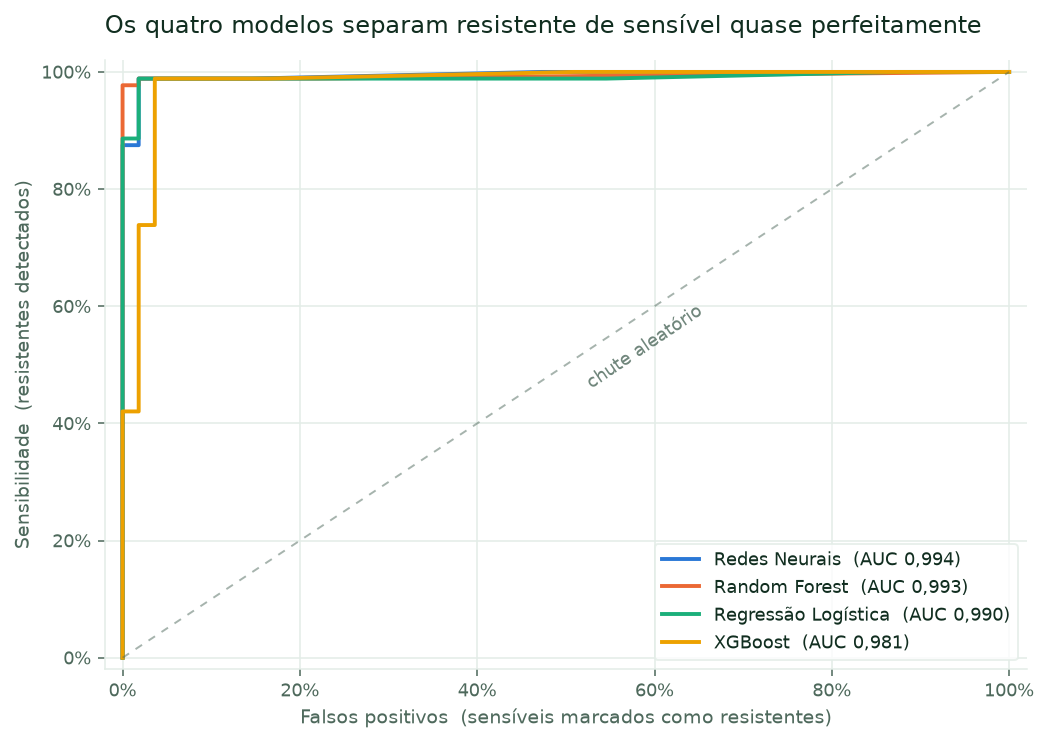

In [45]:
from sklearn.metrics import roc_curve
from matplotlib.ticker import FuncFormatter

# tokens visuais (paleta de séries validada para daltonismo)
INK, INK2, GRID, SURF = "#112E20", "#4E695C", "#E3EDE7", "#FFFFFF"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]

fig, ax = plt.subplots(figsize=(7.6, 5.4), dpi=140, facecolor=SURF)
ax.set_facecolor(SURF)

for cor, nome in zip(SERIES, comparacao.index):          # comparacao já vem ordenada por AUC
    proba = treinados[nome].predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    rotulo = f"{nome}  (AUC {comparacao.loc[nome, 'AUC']:.3f})".replace(".", ",")
    ax.plot(fpr, tpr, color=cor, linewidth=2, label=rotulo)

ax.plot([0, 1], [0, 1], color=INK2, linewidth=1, linestyle=(0, (4, 4)), alpha=.5)
ax.text(.52, .46, "chute aleatório", color=INK2, fontsize=9, rotation=34, alpha=.8)

ax.set_xlim(-.02, 1.02); ax.set_ylim(-.02, 1.02)
ax.set_xlabel("Falsos positivos  (sensíveis marcados como resistentes)", fontsize=10, color=INK2)
ax.set_ylabel("Sensibilidade  (resistentes detectados)", fontsize=10, color=INK2)
ax.set_title("Os quatro modelos separam resistente de sensível quase perfeitamente",
             fontsize=12.5, color=INK, pad=14, loc="left")
for s in ("top", "right"): ax.spines[s].set_visible(False)
for s in ("left", "bottom"): ax.spines[s].set_color(GRID)
ax.tick_params(colors=INK2, labelsize=9)
ax.grid(color=GRID, linewidth=.8); ax.set_axisbelow(True)
pct = FuncFormatter(lambda v, p: f"{v:.0%}")
ax.xaxis.set_major_formatter(pct); ax.yaxis.set_major_formatter(pct)
leg = ax.legend(loc="lower right", frameon=True, fontsize=9.5, facecolor=SURF, edgecolor=GRID)
for t in leg.get_texts(): t.set_color(INK)

plt.tight_layout(); plt.show()

In [46]:
melhor_nome = comparacao.index[0]
prev = treinados[melhor_nome].predict(X_test)
tn, fp, fn, tp = confusion_matrix(y_test, prev).ravel()

print(f"Melhor modelo por AUC: {melhor_nome}\n")
print("                      PREVISTO")
print("                 sensível  resistente")
print(f"REAL sensível     {tn:>6}   {fp:>9}")
print(f"REAL resistente   {fn:>6}   {tp:>9}   <- {fn} falso(s) negativo(s)")
print()
print(f"{fn} de {tp+fn} bactérias resistentes passariam despercebidas.")

Melhor modelo por AUC: Redes Neurais

                      PREVISTO
                 sensível  resistente
REAL sensível         54           1
REAL resistente        1          87   <- 1 falso(s) negativo(s)

1 de 88 bactérias resistentes passariam despercebidas.


# Bloco 11 — Quais genes o modelo usou para decidir

In [47]:
try:
    treinados
except NameError:
    raise SystemExit("Rode o Bloco 8 antes — é ele que cria o dicionário 'treinados'.")

# pega o modelo pelo tipo, não pelo nome (evita erro de acento na chave)
rl = next((m for m in treinados.values() if isinstance(m, LogisticRegression)), None)
rf = next((m for m in treinados.values() if isinstance(m, RandomForestClassifier)), None)

if rl is not None:
    coef = pd.Series(rl.coef_[0], index=X_train.columns).sort_values()
    print("Genes que mais EMPURRAM para resistente:")
    print(coef.tail(8)[::-1].round(3).to_string())

if rf is not None:
    imp = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    print("\nGenes mais importantes para o Random Forest:")
    print(imp.head(8).round(4).to_string())

Genes que mais EMPURRAM para resistente:
gene_gyrA_S91F     3.889
gene_parC_S87R     1.960
gene_gyrA_D95A     1.471
gene_parC_S87N     1.086
gene_gyrA_D95G     0.977
gene_penA_G542S    0.930
gene_gyrA_D95N     0.887
gene_parC_D86N     0.886

Genes mais importantes para o Random Forest:
gene_gyrA_S91F       0.3567
gene_gyrA_D95A       0.1372
gene_parC_S87R       0.0917
gene_ponA_L421P      0.0494
gene_parC_D86N       0.0337
gene_gyrA_D95N       0.0244
gene_porB1b_A121D    0.0238
gene_penA_G542S      0.0228


### Gráfico dos genes mais importantes

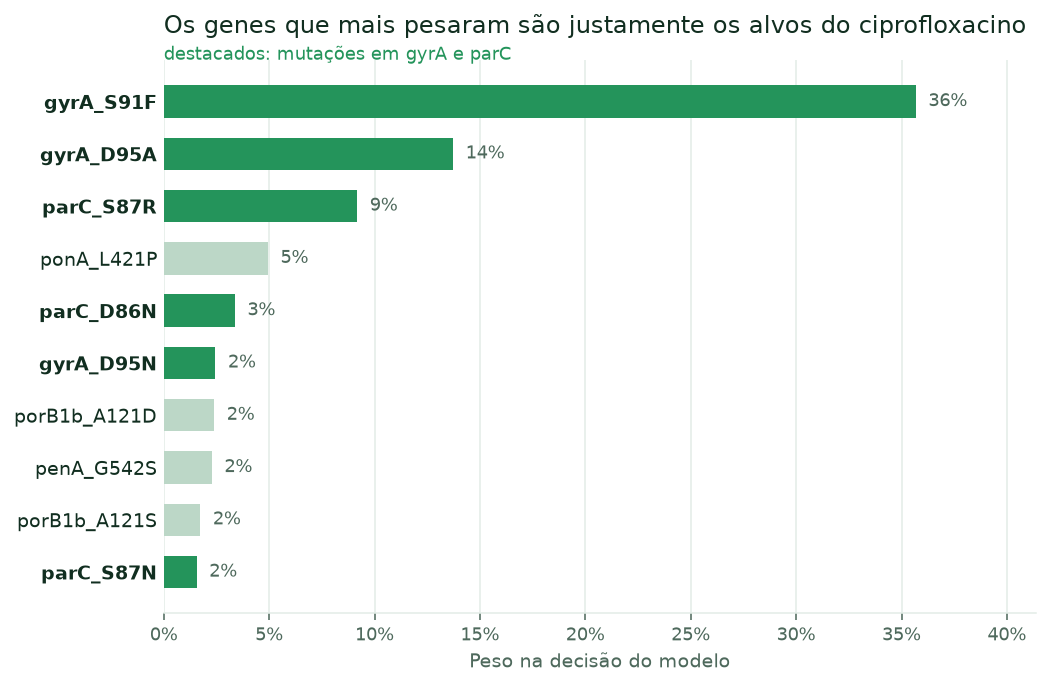

In [48]:
rf = next(m for m in treinados.values() if isinstance(m, RandomForestClassifier))
imp = (pd.Series(rf.feature_importances_, index=X_train.columns)
         .sort_values(ascending=False).head(10)[::-1])
nomes = [g.replace("gene_", "") for g in imp.index]
alvo  = [n.startswith(("gyrA", "parC")) for n in nomes]   # alvos do ciprofloxacino
VERDE = "#24945B"

fig, ax = plt.subplots(figsize=(7.6, 5.0), dpi=140, facecolor=SURF)
ax.set_facecolor(SURF)
ax.barh(range(len(imp)), imp.values, height=.62,
        color=[VERDE if a else "#BCD7C7" for a in alvo], linewidth=0)

for i, v in enumerate(imp.values):
    ax.text(v + .006, i, f"{v:.0%}", va="center", fontsize=9, color=INK2)

ax.set_yticks(range(len(imp))); ax.set_yticklabels(nomes, fontsize=10, color=INK)
for t, a in zip(ax.get_yticklabels(), alvo):
    if a: t.set_fontweight("bold")
ax.set_xlim(0, max(imp.values) * 1.16)
ax.set_xlabel("Peso na decisão do modelo", fontsize=10, color=INK2)
ax.set_title("Os genes que mais pesaram são justamente os alvos do ciprofloxacino",
             fontsize=12.5, color=INK, pad=14, loc="left")
ax.text(0, len(imp) - .2, "destacados: mutações em gyrA e parC", fontsize=9.5, color=VERDE)
for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color(GRID)
ax.tick_params(axis="x", colors=INK2, labelsize=9); ax.tick_params(axis="y", length=0)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, p: f"{v:.0%}"))
ax.grid(axis="x", color=GRID, linewidth=.8); ax.set_axisbelow(True)

plt.tight_layout(); plt.show()

# Bloco 12 — Validação cruzada por cluster

O conjunto de teste tem poucos isolados, então um único sorteio pode dar sorte ou azar.
Aqui a divisão é repetida 5 vezes, sempre respeitando os clusters genéticos.

In [49]:
def auc_cv(criar_modelo, n_splits=5):
    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
    aucs = []
    for i_tr, i_te in cv.split(d, d["target"], groups=grupos):
        tr, te = d.iloc[i_tr], d.iloc[i_te]
        m = MultiLabelBinarizer().fit(tr["genes_list"])
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            Xtr = pd.DataFrame(m.transform(tr["genes_list"]),
                               columns=[f"gene_{g}" for g in m.classes_], index=tr.index)
            Xte = pd.DataFrame(m.transform(te["genes_list"]),
                               columns=[f"gene_{g}" for g in m.classes_], index=te.index)
            keep = Xtr.columns[Xtr.sum() >= MIN_POR_GENE]
            mod = criar_modelo()
            mod.fit(Xtr[keep], tr["target"])
        aucs.append(roc_auc_score(te["target"], mod.predict_proba(Xte[keep])[:, 1]))
    return np.array(aucs)

fabricas = {
    "Regressão Logística": lambda: LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    "Random Forest":       lambda: RandomForestClassifier(n_estimators=400, class_weight="balanced", random_state=42),
    "XGBoost":             lambda: XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.1,
                                                 eval_metric="logloss", random_state=42),
}

print("AUC em 5 divisões diferentes (média ± desvio):\n")
for nome, fab in fabricas.items():
    a = auc_cv(fab)
    print(f"  {nome:<22} {a.mean():.3f} ± {a.std():.3f}   (folds: {np.round(a, 3)})")

AUC em 5 divisões diferentes (média ± desvio):

  Regressão Logística    0.989 ± 0.012   (folds: [0.995 0.999 0.99  0.994 0.966])
  Random Forest          0.987 ± 0.010   (folds: [0.993 0.991 0.991 0.992 0.967])
  XGBoost                0.985 ± 0.009   (folds: [0.976 0.992 0.99  0.993 0.973])
